# Deep Ensemble for 1D Advection-Diffusion-Reaction

This notebook uses `DeepEnsembleRegressor` on a steady 1D
advection-diffusion-reaction problem. The ensemble learns a pointwise map
from coordinate and PDE parameters to the solution value.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'sciml':
    PROJECT = ROOT.parents[1]
else:
    PROJECT = ROOT
SRC = PROJECT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import math
import random

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import DeepEnsembleRegressor
from deepuq.models import MLP

torch.manual_seed(7)
random.seed(7)

## Physical problem

We solve

$$
- D u''(x) + v u'(x) + r u(x) = s(x), \qquad x\in[0,1], \qquad u(0)=u(1)=0.
$$

- $D$ controls diffusion,
- $v$ controls directed transport,
- $r$ is a linear reaction term,
- $s(x)$ is the source field.

The in-domain training set only uses mild source frequencies. OOD samples use
sharper forcing and stronger transport.

In [3]:
def solve_adr_1d(params, n_grid=128):
    a, b, c, diff, adv, react = params
    x = torch.linspace(0.0, 1.0, n_grid)
    h = float(x[1] - x[0])
    interior = n_grid - 2
    main = torch.full((interior,), 2.0 * diff / h**2 + react)
    lower = torch.full((interior - 1,), -diff / h**2 - adv / (2.0 * h))
    upper = torch.full((interior - 1,), -diff / h**2 + adv / (2.0 * h))
    A = torch.diag(main) + torch.diag(lower, diagonal=-1) + torch.diag(upper, diagonal=1)
    source = a * torch.sin(math.pi * b * x[1:-1]) + c * torch.cos(2.0 * math.pi * x[1:-1])
    interior_u = torch.linalg.solve(A, source)
    u = torch.zeros_like(x)
    u[1:-1] = interior_u
    return x, u


def sample_params(n, *, ood=False):
    rows = []
    for _ in range(n):
        if ood:
            rows.append((random.uniform(1.2, 1.8), random.uniform(3.5, 5.0), random.uniform(-0.5, 0.5), random.uniform(0.04, 0.09), random.uniform(0.8, 1.2), random.uniform(0.4, 0.8)))
        else:
            rows.append((random.uniform(0.7, 1.3), random.uniform(1.0, 3.0), random.uniform(-0.25, 0.25), random.uniform(0.06, 0.12), random.uniform(0.2, 0.8), random.uniform(0.1, 0.5)))
    return rows


def make_pointwise_dataset(param_rows, n_grid=128):
    feats = []
    targets = []
    curves = []
    for params in param_rows:
        x, u = solve_adr_1d(params, n_grid=n_grid)
        param_tensor = torch.tensor(params, dtype=torch.float32).repeat(n_grid, 1)
        feats.append(torch.cat([x.unsqueeze(1), param_tensor], dim=1))
        targets.append(u.unsqueeze(1))
        curves.append((x, u, params))
    return torch.cat(feats, dim=0), torch.cat(targets, dim=0), curves

In [4]:
train_x, train_y, _ = make_pointwise_dataset(sample_params(80))
test_x, test_y, test_curves = make_pointwise_dataset(sample_params(20))
ood_x, ood_y, ood_curves = make_pointwise_dataset(sample_params(20, ood=True))

loader = DataLoader(TensorDataset(train_x, train_y), batch_size=256, shuffle=True)
ensemble = DeepEnsembleRegressor([MLP(7, [64, 64, 64], 1, p_drop=0.0) for _ in range(5)])
ensemble.fit(loader, epochs=80, lr=1e-3, weight_decay=1e-5, seed=123)

DeepEnsembleRegressor(
  (models): ModuleList(
    (0-4): 5 x MLP(
      (net): Sequential(
        (0): Linear(in_features=7, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=64, out_features=64, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.0, inplace=False)
        (6): Linear(in_features=64, out_features=64, bias=True)
        (7): ReLU()
        (8): Dropout(p=0.0, inplace=False)
        (9): Linear(in_features=64, out_features=1, bias=True)
      )
    )
  )
)

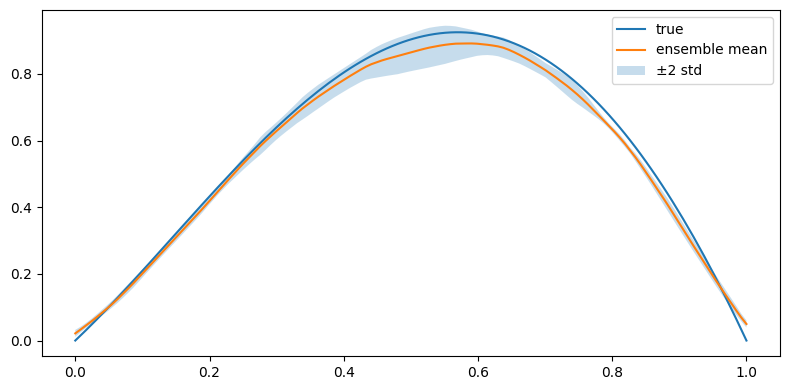

In [5]:
x, u_true, params = test_curves[0]
features = torch.cat([x.unsqueeze(1), torch.tensor(params, dtype=torch.float32).repeat(x.numel(), 1)], dim=1)
uq = ensemble.predict_uq(features)
mean = uq.mean.squeeze(-1)
std = uq.total_var.sqrt().squeeze(-1)

plt.figure(figsize=(8, 4))
plt.plot(x, u_true, label='true')
plt.plot(x, mean, label='ensemble mean')
plt.fill_between(x.numpy(), (mean - 2 * std).numpy(), (mean + 2 * std).numpy(), alpha=0.25, label='±2 std')
plt.legend(); plt.tight_layout()